<a href="https://colab.research.google.com/github/Nicolas-1802/ColabProjects/blob/main/Overview_of_Colaboratory_Features.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Projeto M2 - Processamento de Imagens
# Segmentação clássica de lesões de pele - ISIC
# Alunos: Gabrielly C. de Andrade e Nicolas F. Teixeira

In [77]:
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import kagglehub

1. Download automático do dataset


In [ ]:
!pip install -q kagglehub

In [78]:
DATASET_PATH = kagglehub.dataset_download("paultimothymooney/blood-cells")

print("Dataset baixado em:")
print(DATASET_PATH)

# Procura imagens
image_files = []
for ext in ["*.jpg", "*.jpeg", "*.png"]:
    image_files.extend(glob.glob(DATASET_PATH + "/**/" + ext, recursive=True))

image_files = sorted(image_files)

print("Total de imagens encontradas:", len(image_files))

print("\nPrimeiras imagens encontradas:")
for p in image_files[:10]:
    print(p)

if len(image_files) == 0:
    raise Exception("Nenhuma imagem foi encontrada. Verifique se o dataset baixou corretamente.")

Using Colab cache for faster access to the 'blood-cells' dataset.
Dataset baixado em:
/kaggle/input/blood-cells
Total de imagens encontradas: 12881

Primeiras imagens encontradas:
/kaggle/input/blood-cells/dataset-master/dataset-master/JPEGImages/BloodImage_00000.jpg
/kaggle/input/blood-cells/dataset-master/dataset-master/JPEGImages/BloodImage_00001.jpg
/kaggle/input/blood-cells/dataset-master/dataset-master/JPEGImages/BloodImage_00002.jpg
/kaggle/input/blood-cells/dataset-master/dataset-master/JPEGImages/BloodImage_00003.jpg
/kaggle/input/blood-cells/dataset-master/dataset-master/JPEGImages/BloodImage_00004.jpg
/kaggle/input/blood-cells/dataset-master/dataset-master/JPEGImages/BloodImage_00005.jpg
/kaggle/input/blood-cells/dataset-master/dataset-master/JPEGImages/BloodImage_00006.jpg
/kaggle/input/blood-cells/dataset-master/dataset-master/JPEGImages/BloodImage_00007.jpg
/kaggle/input/blood-cells/dataset-master/dataset-master/JPEGImages/BloodImage_00008.jpg
/kaggle/input/blood-cells/da

2. Funções básicas de leitura e conversão

In [79]:
def load_image(path, size=(256, 256)):
    img = Image.open(path).convert("RGB")
    img = img.resize(size)
    return np.asarray(img).astype(np.float32) / 255.0


def rgb_to_gray(img):
    return 0.299 * img[:, :, 0] + 0.587 * img[:, :, 1] + 0.114 * img[:, :, 2]


def normalize01(x):
    x = x.astype(np.float32)
    mn = x.min()
    mx = x.max()

    if mx - mn < 1e-8:
        return np.zeros_like(x)

    return (x - mn) / (mx - mn)

3. Conversão RGB para HSV

In [80]:
def rgb_to_hsv_manual(img):
    r = img[:, :, 0]
    g = img[:, :, 1]
    b = img[:, :, 2]

    maxc = np.maximum(np.maximum(r, g), b)
    minc = np.minimum(np.minimum(r, g), b)
    delta = maxc - minc

    h = np.zeros_like(maxc)

    mask = delta > 1e-8

    idx = mask & (maxc == r)
    h[idx] = ((g[idx] - b[idx]) / delta[idx]) % 6

    idx = mask & (maxc == g)
    h[idx] = ((b[idx] - r[idx]) / delta[idx]) + 2

    idx = mask & (maxc == b)
    h[idx] = ((r[idx] - g[idx]) / delta[idx]) + 4

    h = h / 6.0

    s = np.zeros_like(maxc)
    s[maxc > 1e-8] = delta[maxc > 1e-8] / maxc[maxc > 1e-8]

    v = maxc

    hsv = np.stack([h, s, v], axis=2)
    return hsv

4. Filtro passa-baixa no domínio da frequência

In [81]:
def low_pass_fft(gray, radius=30):
    h, w = gray.shape

    F = np.fft.fft2(gray)
    F_shift = np.fft.fftshift(F)

    cy = h // 2
    cx = w // 2

    y, x = np.ogrid[:h, :w]
    dist = np.sqrt((y - cy) ** 2 + (x - cx) ** 2)

    mask = dist <= radius

    F_filtered = F_shift * mask

    img_back = np.fft.ifft2(np.fft.ifftshift(F_filtered))
    img_back = np.abs(img_back)

    return normalize01(img_back)

5. Otsu

In [82]:
def otsu_threshold(values, bins=256):
    values = values.astype(np.float32)
    values = values[np.isfinite(values)]
    values = values[(values >= 0) & (values <= 1)]

    if len(values) == 0:
        return 0.5

    hist, bin_edges = np.histogram(values, bins=bins, range=(0, 1))
    hist = hist.astype(np.float64)

    total = hist.sum()

    if total == 0:
        return 0.5

    prob = hist / total
    centers = (bin_edges[:-1] + bin_edges[1:]) / 2

    best_t = 0.5
    best_var = -1

    for i in range(1, bins - 1):
        w0 = prob[:i].sum()
        w1 = prob[i:].sum()

        if w0 == 0 or w1 == 0:
            continue

        m0 = (prob[:i] * centers[:i]).sum() / w0
        m1 = (prob[i:] * centers[i:]).sum() / w1

        var_between = w0 * w1 * (m0 - m1) ** 2

        if var_between > best_var:
            best_var = var_between
            best_t = centers[i]

    return best_t

6. SLIC

In [106]:
def slic_from_scratch(img, num_superpixels=300, compactness=0.25, iterations=8):
    h, w, c = img.shape

    n_pixels = h * w
    step = int(np.sqrt(n_pixels / num_superpixels))
    step = max(step, 4)

    centers = []

    for y in range(step // 2, h, step):
        for x in range(step // 2, w, step):
            color = img[y, x]
            centers.append([
                y,
                x,
                color[0],
                color[1],
                color[2]
            ])

    centers = np.array(centers, dtype=np.float32)

    k = len(centers)

    labels = -np.ones((h, w), dtype=np.int32)
    distances = np.full((h, w), np.inf, dtype=np.float32)

    yy, xx = np.mgrid[0:h, 0:w]

    for it in range(iterations):
        distances[:, :] = np.inf

        for idx, center in enumerate(centers):
            cy, cx, cr, cg, cb = center

            y0 = int(max(cy - step, 0))
            y1 = int(min(cy + step, h))

            x0 = int(max(cx - step, 0))
            x1 = int(min(cx + step, w))

            region = img[y0:y1, x0:x1]

            ry = yy[y0:y1, x0:x1]
            rx = xx[y0:y1, x0:x1]

            dc = np.sqrt(
                (region[:, :, 0] - cr) ** 2 +
                (region[:, :, 1] - cg) ** 2 +
                (region[:, :, 2] - cb) ** 2
            )

            ds = np.sqrt((ry - cy) ** 2 + (rx - cx) ** 2)

            # Correção importante:
            # Como a cor está em escala 0-1, o peso espacial precisa ser pequeno.
            D = dc + compactness * (ds / step)

            current = distances[y0:y1, x0:x1]
            update = D < current

            current[update] = D[update]
            distances[y0:y1, x0:x1] = current

            sublabels = labels[y0:y1, x0:x1]
            sublabels[update] = idx
            labels[y0:y1, x0:x1] = sublabels

        for idx in range(k):
            ys, xs = np.where(labels == idx)

            if len(ys) == 0:
                continue

            mean_y = ys.mean()
            mean_x = xs.mean()
            mean_color = img[ys, xs].mean(axis=0)

            centers[idx] = [
                mean_y,
                mean_x,
                mean_color[0],
                mean_color[1],
                mean_color[2]
            ]

    return labels

7. Morfologia matemática from scratch


In [84]:
def binary_erosion(mask, kernel_size=3):
    pad = kernel_size // 2
    padded = np.pad(mask, pad, mode="constant", constant_values=0)

    h, w = mask.shape
    out = np.zeros_like(mask)

    for y in range(h):
        for x in range(w):
            region = padded[y:y + kernel_size, x:x + kernel_size]

            if np.all(region == 1):
                out[y, x] = 1

    return out


def binary_dilation(mask, kernel_size=3):
    pad = kernel_size // 2
    padded = np.pad(mask, pad, mode="constant", constant_values=0)

    h, w = mask.shape
    out = np.zeros_like(mask)

    for y in range(h):
        for x in range(w):
            region = padded[y:y + kernel_size, x:x + kernel_size]

            if np.any(region == 1):
                out[y, x] = 1

    return out


def opening(mask, kernel_size=3):
    return binary_dilation(binary_erosion(mask, kernel_size), kernel_size)


def closing(mask, kernel_size=3):
    return binary_erosion(binary_dilation(mask, kernel_size), kernel_size)


def connected_components(mask):
    h, w = mask.shape

    labels = np.zeros((h, w), dtype=np.int32)
    current_label = 0
    areas = {}

    for y in range(h):
        for x in range(w):
            if mask[y, x] == 1 and labels[y, x] == 0:
                current_label += 1

                stack = [(y, x)]
                labels[y, x] = current_label
                area = 0

                while len(stack) > 0:
                    cy, cx = stack.pop()
                    area += 1

                    for dy, dx in [(-1, 0), (1, 0), (0, -1), (0, 1)]:
                        ny = cy + dy
                        nx = cx + dx

                        if 0 <= ny < h and 0 <= nx < w:
                            if mask[ny, nx] == 1 and labels[ny, nx] == 0:
                                labels[ny, nx] = current_label
                                stack.append((ny, nx))

                areas[current_label] = area

    return labels, areas


def remove_small_components(mask, min_area=80):
    labels, areas = connected_components(mask)

    out = np.zeros_like(mask)

    for lab, area in areas.items():
        if area >= min_area:
            out[labels == lab] = 1

    return out


def fill_holes(mask):
    h, w = mask.shape

    inv = 1 - mask
    visited = np.zeros_like(inv, dtype=np.uint8)

    stack = []

    for x in range(w):
        if inv[0, x] == 1:
            stack.append((0, x))
            visited[0, x] = 1

        if inv[h - 1, x] == 1:
            stack.append((h - 1, x))
            visited[h - 1, x] = 1

    for y in range(h):
        if inv[y, 0] == 1:
            stack.append((y, 0))
            visited[y, 0] = 1

        if inv[y, w - 1] == 1:
            stack.append((y, w - 1))
            visited[y, w - 1] = 1

    while len(stack) > 0:
        cy, cx = stack.pop()

        for dy, dx in [(-1, 0), (1, 0), (0, -1), (0, 1)]:
            ny = cy + dy
            nx = cx + dx

            if 0 <= ny < h and 0 <= nx < w:
                if inv[ny, nx] == 1 and visited[ny, nx] == 0:
                    visited[ny, nx] = 1
                    stack.append((ny, nx))

    holes = (inv == 1) & (visited == 0)

    filled = mask.copy()
    filled[holes] = 1

    return filled.astype(np.uint8)


8. SCORE PARA DESTACAR CÉLULAS

In [112]:
def blood_cell_score(img):
    hsv = rgb_to_hsv_manual(img)

    gray = rgb_to_gray(img)
    saturation = hsv[:, :, 1]

    r = img[:, :, 0]
    g = img[:, :, 1]
    b = img[:, :, 2]

    # Fundo claro fica próximo de branco.
    distance_from_white = np.sqrt(
        (1.0 - r) ** 2 +
        (1.0 - g) ** 2 +
        (1.0 - b) ** 2
    )
    distance_from_white = normalize01(distance_from_white)

    # Células costumam ter mais saturação que o fundo.
    sat_score = normalize01(saturation)

    # Partes celulares são geralmente mais escuras que o fundo.
    dark_score = normalize01(1.0 - gray)

    # Realça células rosadas/arroxeadas.
    color_score = normalize01((r + b) / 2.0 - g)

    score = (
        0.35 * distance_from_white +
        0.30 * sat_score +
        0.20 * dark_score +
        0.15 * color_score
    )

    return normalize01(score)

9. SEGMENTAÇÃO POR SUPERPIXEL + OTSU

In [86]:
def segment_by_superpixel_otsu(img, labels, score_img):
    unique_labels = np.unique(labels)

    superpixel_values = []

    for lab in unique_labels:
        region = labels == lab
        value = score_img[region].mean()
        superpixel_values.append(value)

    superpixel_values = np.array(superpixel_values)

    threshold = otsu_threshold(superpixel_values)

    mask = np.zeros(labels.shape, dtype=np.uint8)

    for lab, value in zip(unique_labels, superpixel_values):
        if value >= threshold:
            mask[labels == lab] = 1

    # Controle para evitar segmentação exagerada
    if mask.mean() > 0.65:
        threshold = np.percentile(superpixel_values, 70)

        mask = np.zeros(labels.shape, dtype=np.uint8)

        for lab, value in zip(unique_labels, superpixel_values):
            if value >= threshold:
                mask[labels == lab] = 1

    return mask


10. PÓS-PROCESSAMENTO MORFOLÓGICO

In [110]:
def post_process(mask):
    result = opening(mask, kernel_size=3)
    result = closing(result, kernel_size=5)
    result = fill_holes(result)
    result = remove_small_components(result, min_area=80)
    result = closing(result, kernel_size=5)

    return result.astype(np.uint8)

11. AVALIAÇÃO QUANTITATIVA

In [103]:
def evaluate_segmentation(raw_mask, final_mask):
    raw_labels, raw_areas = connected_components(raw_mask)
    final_labels, final_areas = connected_components(final_mask)

    raw_count = len(raw_areas)
    final_count = len(final_areas)

    removed_objects = raw_count - final_count

    total_pixels = final_mask.shape[0] * final_mask.shape[1]
    segmented_pixels = final_mask.sum()

    if final_count == 0:
        return {
            "Objetos_antes_pos_processamento": raw_count,
            "Objetos_finais_segmentados": 0,
            "Objetos_removidos": removed_objects,
            "Area_total_segmentada": 0,
            "Area_media_dos_objetos": 0,
            "Maior_objeto": 0,
            "Menor_objeto": 0,
            "Percentual_imagem_segmentada": 0
        }

    area_values = list(final_areas.values())

    return {
        "Objetos_antes_pos_processamento": raw_count,
        "Objetos_finais_segmentados": final_count,
        "Objetos_removidos": removed_objects,
        "Area_total_segmentada": int(np.sum(area_values)),
        "Area_media_dos_objetos": float(np.mean(area_values)),
        "Maior_objeto": int(np.max(area_values)),
        "Menor_objeto": int(np.min(area_values)),
        "Percentual_imagem_segmentada": float(segmented_pixels / total_pixels)
    }

12. Seleção automática de 5 imagens difíceis

In [104]:
def difficulty_score(img_path):
    img = load_image(img_path)

    gray = rgb_to_gray(img)
    hsv = rgb_to_hsv_manual(img)

    saturation = hsv[:, :, 1]

    # Baixo contraste global
    contrast = gray.std()

    # Alta variação de saturação indica coloração mais complexa
    sat_var = saturation.std()

    # Score de cor
    score = blood_cell_score(img)

    # Quanto mais ambígua a separação por Otsu, mais difícil
    t = otsu_threshold(score.flatten())
    foreground = score >= t
    area_ratio = foreground.mean()

    area_difficulty = 1.0 - abs(area_ratio - 0.25)

    # Dificuldade final
    difficulty = (
        0.35 * (1.0 / (contrast + 1e-6)) +
        0.35 * sat_var +
        0.30 * area_difficulty
    )

    return difficulty


scored = []

# Analisa uma amostra do dataset para não demorar muito
candidate_files = image_files[:300]

for p in candidate_files:
    try:
        s = difficulty_score(p)
        scored.append((s, p))
    except:
        pass

scored = sorted(scored, reverse=True, key=lambda x: x[0])

NUM_IMAGES = 5
selected_images = [p for s, p in scored[:NUM_IMAGES]]

print("\nImagens difíceis selecionadas:")
for s, p in scored[:NUM_IMAGES]:
    print(f"{os.path.basename(p)} | dificuldade = {s:.4f}")


Imagens difíceis selecionadas:
BloodImage_00167.jpg | dificuldade = 6.3691
BloodImage_00253.jpg | dificuldade = 6.2750
BloodImage_00281.jpg | dificuldade = 6.2268
BloodImage_00252.jpg | dificuldade = 6.2097
BloodImage_00164.jpg | dificuldade = 5.7741


11. Pipeline completo


Processando imagem: 1
BloodImage_00167.jpg
Pixels alterados pela morfologia: 2674
Percentual alterado: 0.040802001953125
Métricas da imagem:
Objetos_antes_pos_processamento: 16
Objetos_finais_segmentados: 16
Objetos_removidos: 0
Area_total_segmentada: 22058
Area_media_dos_objetos: 1378.625
Maior_objeto: 3841
Menor_objeto: 197
Percentual_imagem_segmentada: 0.336578369140625
Máscara salva em: /content/mascaras_binarias_celulas/mascara_binaria_celulas_1.png


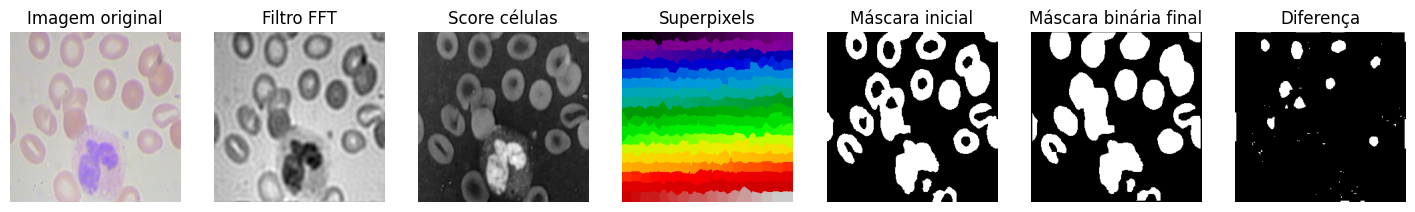


Processando imagem: 2
BloodImage_00253.jpg
Pixels alterados pela morfologia: 1921
Percentual alterado: 0.0293121337890625
Métricas da imagem:
Objetos_antes_pos_processamento: 9
Objetos_finais_segmentados: 8
Objetos_removidos: 1
Area_total_segmentada: 28201
Area_media_dos_objetos: 3525.125
Maior_objeto: 11386
Menor_objeto: 159
Percentual_imagem_segmentada: 0.4303131103515625
Máscara salva em: /content/mascaras_binarias_celulas/mascara_binaria_celulas_2.png


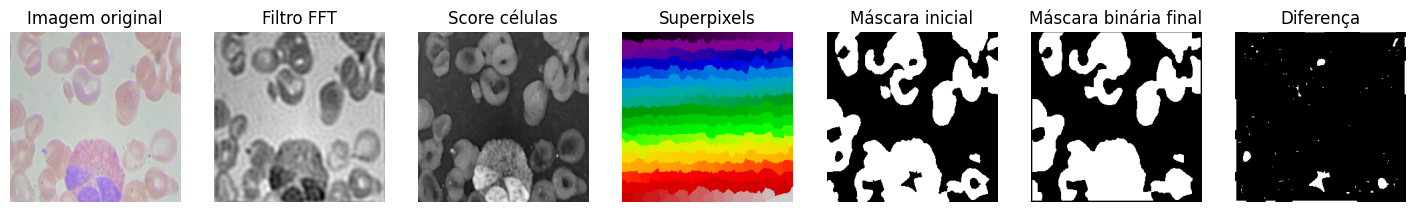


Processando imagem: 3
BloodImage_00281.jpg
Pixels alterados pela morfologia: 882
Percentual alterado: 0.013458251953125
Métricas da imagem:
Objetos_antes_pos_processamento: 15
Objetos_finais_segmentados: 14
Objetos_removidos: 1
Area_total_segmentada: 14397
Area_media_dos_objetos: 1028.357142857143
Maior_objeto: 6251
Menor_objeto: 114
Percentual_imagem_segmentada: 0.2196807861328125
Máscara salva em: /content/mascaras_binarias_celulas/mascara_binaria_celulas_3.png


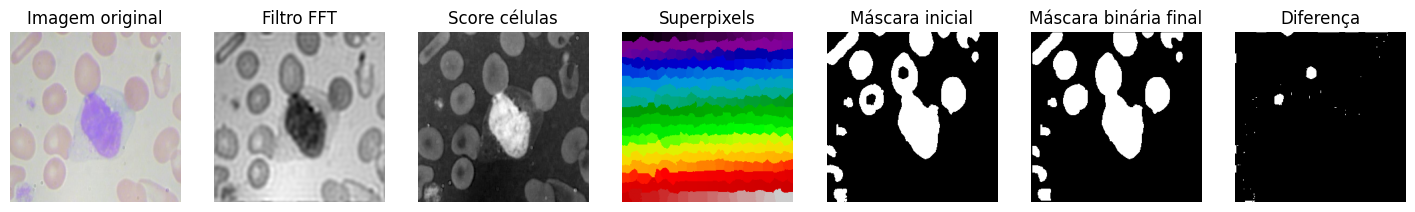


Processando imagem: 4
BloodImage_00252.jpg
Pixels alterados pela morfologia: 969
Percentual alterado: 0.0147857666015625
Métricas da imagem:
Objetos_antes_pos_processamento: 18
Objetos_finais_segmentados: 18
Objetos_removidos: 0
Area_total_segmentada: 21463
Area_media_dos_objetos: 1192.388888888889
Maior_objeto: 7512
Menor_objeto: 161
Percentual_imagem_segmentada: 0.3274993896484375
Máscara salva em: /content/mascaras_binarias_celulas/mascara_binaria_celulas_4.png


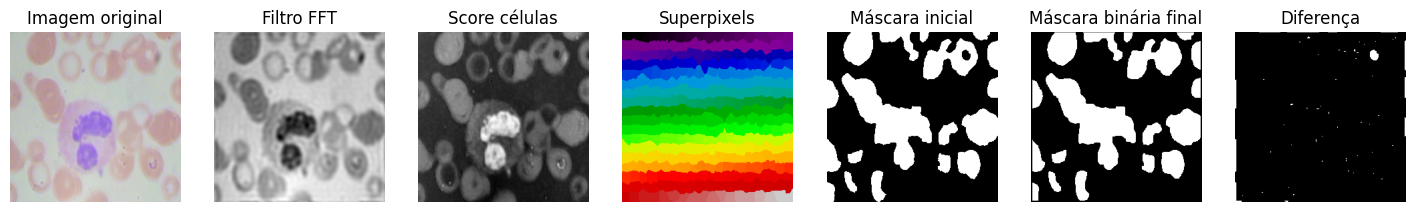


Processando imagem: 5
BloodImage_00164.jpg
Pixels alterados pela morfologia: 1975
Percentual alterado: 0.0301361083984375
Métricas da imagem:
Objetos_antes_pos_processamento: 13
Objetos_finais_segmentados: 12
Objetos_removidos: 1
Area_total_segmentada: 29887
Area_media_dos_objetos: 2490.5833333333335
Maior_objeto: 11713
Menor_objeto: 125
Percentual_imagem_segmentada: 0.4560394287109375
Máscara salva em: /content/mascaras_binarias_celulas/mascara_binaria_celulas_5.png


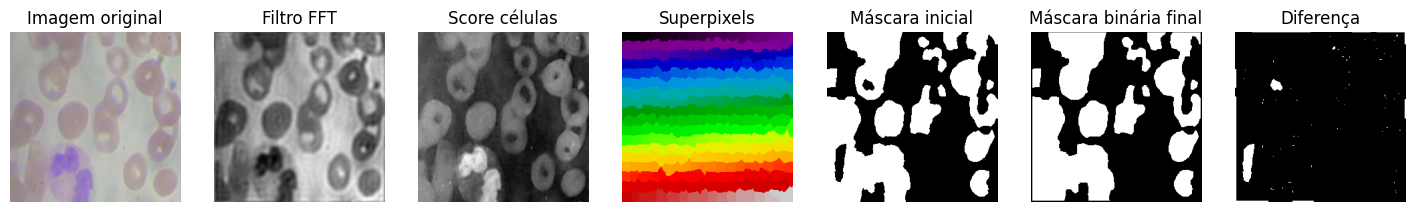

In [113]:
OUTPUT_DIR = "/content/mascaras_binarias_celulas"
os.makedirs(OUTPUT_DIR, exist_ok=True)

all_metrics = []

for idx, img_path in enumerate(selected_images):
    print("\n========================================")
    print("Processando imagem:", idx + 1)
    print(os.path.basename(img_path))
    print("========================================")

    img = load_image(img_path)

    gray = rgb_to_gray(img)

    # Etapa 1: pré-processamento e score de célula
    score_img = blood_cell_score(img)

    # Etapa 2: filtragem em frequência
    filtered_gray = low_pass_fft(gray, radius=28)

    # Etapa 3: segmentação por superpixels
    labels = slic_from_scratch(
        img,
        num_superpixels=300,
        compactness=0.25,
        iterations=8
    )

    raw_mask = segment_by_superpixel_otsu(
        img,
        labels,
        score_img
    )

    # Etapa 4: morfologia matemática
    final_mask = post_process(raw_mask)

    diferenca = np.abs(final_mask.astype(int) - raw_mask.astype(int))

    print("Pixels alterados pela morfologia:", diferenca.sum())
    print("Percentual alterado:", diferenca.sum() / diferenca.size)

    # Etapa 5: avaliação quantitativa
    metrics = evaluate_segmentation(raw_mask, final_mask)

    all_metrics.append(metrics)

    print("Métricas da imagem:")

    for key, value in metrics.items():
        print(f"{key}: {value}")

    # Salvar máscara binária
    mask_to_save = (final_mask * 255).astype(np.uint8)

    output_name = f"mascara_binaria_celulas_{idx + 1}.png"
    output_path = os.path.join(OUTPUT_DIR, output_name)

    Image.fromarray(mask_to_save).save(output_path)

    print("Máscara salva em:", output_path)

    # Visualização
    plt.figure(figsize=(18, 4))

    plt.subplot(1, 7, 1)
    plt.imshow(img)
    plt.title("Imagem original")
    plt.axis("off")

    plt.subplot(1, 7, 2)
    plt.imshow(filtered_gray, cmap="gray")
    plt.title("Filtro FFT")
    plt.axis("off")

    plt.subplot(1, 7, 3)
    plt.imshow(score_img, cmap="gray")
    plt.title("Score células")
    plt.axis("off")

    plt.subplot(1, 7, 4)
    plt.imshow(labels, cmap="nipy_spectral")
    plt.title("Superpixels")
    plt.axis("off")

    plt.subplot(1, 7, 5)
    plt.imshow(raw_mask, cmap="gray", vmin=0, vmax=1)
    plt.title("Máscara inicial")
    plt.axis("off")

    plt.subplot(1, 7, 6)
    plt.imshow(final_mask, cmap="gray", vmin=0, vmax=1)
    plt.title("Máscara binária final")
    plt.axis("off")

    plt.subplot(1, 7, 7)
    plt.imshow(diferenca, cmap="gray")
    plt.title("Diferença")
    plt.axis("off")

    plt.show()

11. Resultado médio

In [101]:
print("\n========================================")
print("RESULTADOS POR IMAGEM")
print("========================================")

for i, metrics in enumerate(all_metrics):
    print(f"\nImagem {i + 1}")

    for key, value in metrics.items():
        print(f"{key}: {value}")


RESULTADOS POR IMAGEM

Imagem 1
Objetos_antes_pos_processamento: 11
Objetos_finais_segmentados: 11
Objetos_removidos: 0
Area_total_segmentada: 16914
Area_media_dos_objetos: 1537.6363636363637
Maior_objeto: 3940
Menor_objeto: 320
Percentual_imagem_segmentada: 0.258087158203125

Imagem 2
Objetos_antes_pos_processamento: 6
Objetos_finais_segmentados: 6
Objetos_removidos: 0
Area_total_segmentada: 27628
Area_media_dos_objetos: 4604.666666666667
Maior_objeto: 9471
Menor_objeto: 361
Percentual_imagem_segmentada: 0.42156982421875

Imagem 3
Objetos_antes_pos_processamento: 3
Objetos_finais_segmentados: 3
Objetos_removidos: 0
Area_total_segmentada: 6080
Area_media_dos_objetos: 2026.6666666666667
Maior_objeto: 4693
Menor_objeto: 665
Percentual_imagem_segmentada: 0.0927734375

Imagem 4
Objetos_antes_pos_processamento: 8
Objetos_finais_segmentados: 8
Objetos_removidos: 0
Area_total_segmentada: 14093
Area_media_dos_objetos: 1761.625
Maior_objeto: 6571
Menor_objeto: 437
Percentual_imagem_segmentada: